# Comparación de modelos

Comparamos los cuatro modelos entrenados sobre el mismo split (submuestra de 600 imágenes/clase, 64x64, mismo `train`/`val`/`test`):

- **Random Forest** (`randomForest.ipynb`)
- **CNN simple** (`cnn_simple.ipynb`)
- **CNN profunda** (`cnn_profunda.ipynb`)
- **Red neuronal simple / fully-connected** (`redesNeuronalesSimple.ipynb`)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = {
    "Random Forest": 0.9655,
    "CNN simple": 0.9644,
    "CNN profunda": 0.9866,
    "Red simple (fully-connected)": None,  # PENDIENTE
}

df_comparacion = pd.DataFrame({
    "modelo": list(resultados.keys()),
    "accuracy_test": list(resultados.values()),
})
df_comparacion

,modelo,accuracy_test
0,Random Forest,0.9655
1,CNN simple,0.9644
2,CNN profunda,0.9866
3,Red simple (fully-connected),NaN


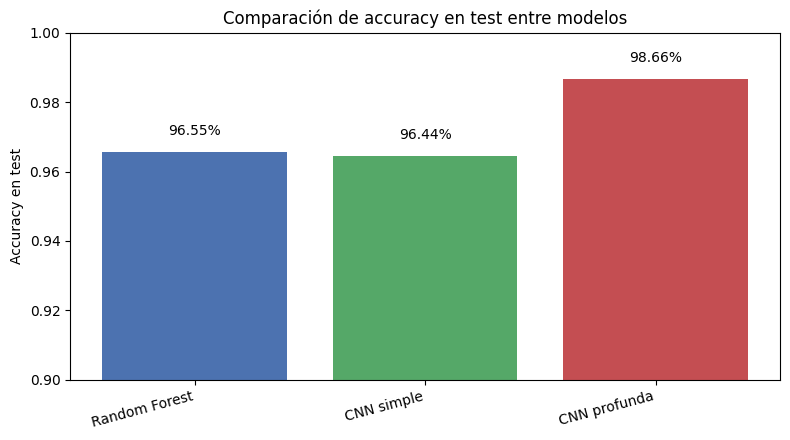

In [2]:
df_plot = df_comparacion.dropna()

plt.figure(figsize=(8, 4.5))
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
barras = plt.bar(df_plot["modelo"], df_plot["accuracy_test"], color=colores[:len(df_plot)])

for barra, valor in zip(barras, df_plot["accuracy_test"]):
    plt.text(barra.get_x() + barra.get_width() / 2, valor + 0.005, f"{valor:.2%}",
             ha="center", fontsize=10)

plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy en test")
plt.title("Comparación de accuracy en test entre modelos")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Discusión

**La CNN profunda es el mejor modelo** con 98.66% de accuracy en test, por encima de Random Forest (96.55%) y la CNN simple (96.44%), que quedan prácticamente empatados entre sí (0.11 puntos de diferencia, dentro del ruido esperado entre dos algoritmos tan distintos).

**¿Por qué gana la CNN profunda?** Tiene más capacidad (4 bloques de convolución con 32 a 256 filtros, batch normalization) para capturar detalles finos de la forma de la mano que distinguen letras parecidas. En su reporte de clasificación, los únicos puntos débiles son D, O y R (recall ~0.93-0.96), muy por encima del peor caso de la CNN simple (U con recall 0.93 y precisión 0.84) o de Random Forest (E y W con recall 0.88).

**Random Forest vs. CNN simple**: terminan casi empatados en accuracy, pero por caminos distintos. Random Forest ni siquiera ve la imagen como imagen, ya que trabaja con los píxeles aplanados en un solo vector, y aun así alcanza a una CNN. Esto sugiere que con esta cantidad de datos (17,400 imágenes) y esta resolución (64x64) ambos modelos ya están cerca del máximo que pueden dar, y que hace falta más capacidad, como la de la CNN profunda, para seguir mejorando.

**Costo de esa mejora**: la CNN profunda también fue la más lenta de entrenar, con unos 16 a 18 segundos por época contra apenas 4 segundos de la CNN simple. 

**Selección para el resto del laboratorio**: con estos resultados, la **CNN profunda** es la candidata natural para el ejercicio 8 (pruebas con fotos propias) y para las conclusiones del ejercicio 9 (accesibilidad), al ser el modelo más acertado del grupo.